# Without np.fft

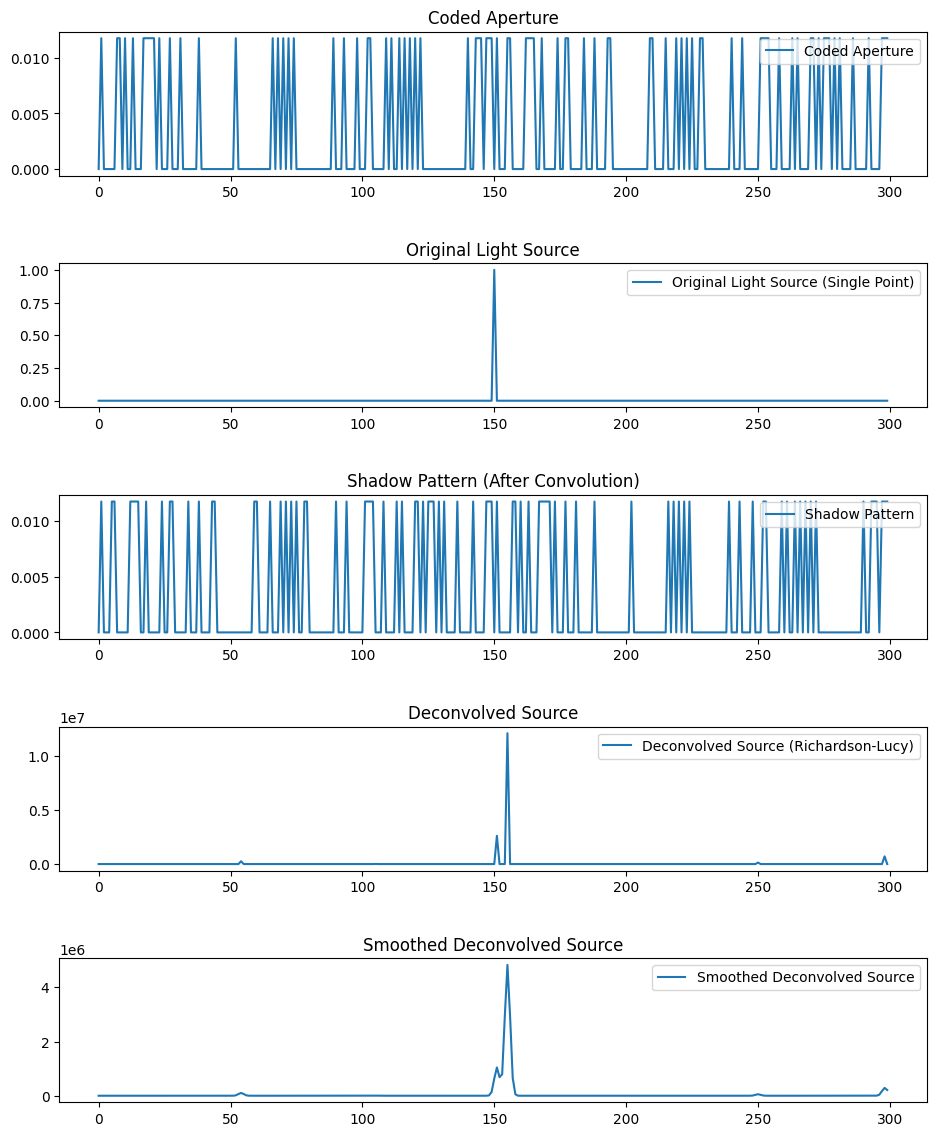

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter

def generate_coded_aperture(length, density):
    np.random.seed(0)
    aperture = np.random.choice([0, 1], size=length, p=[1 - density, density])
    aperture = aperture / np.sum(aperture)
    return aperture

def generate_point_source(length, position):
    source = np.zeros(length)
    source[position] = 1
    return source

def compute_dft(y):
    N = len(y)
    n = np.arange(N)
    k = n.reshape((N, 1))
    e = np.exp(-2j * np.pi * k * n / N)
    Y = np.dot(e, y)
    return Y

def compute_idft(Y):
    N = len(Y)
    n = np.arange(N)
    k = n.reshape((N, 1))
    e = np.exp(2j * np.pi * k * n / N)
    y = np.dot(e, Y) / N
    return np.real(y)

def dft_convolution(source, aperture):
    source_dft = compute_dft(source)
    aperture_dft = compute_dft(aperture)

    shadow_dft = source_dft * aperture_dft

    shadow_pattern = compute_idft(shadow_dft)

    return shadow_pattern

# Richardson-Lucy Deconvolution Algorithm
def richardson_lucy(observed, psf, iterations=50):
    estimate = np.ones_like(observed)

    psf = psf / np.sum(psf)

    for _ in range(iterations):
        estimate_convolved = dft_convolution(estimate, psf)
        estimate_convolved[estimate_convolved == 0] = 1e-10
        relative_blur = observed / estimate_convolved
        psf_flipped = np.flip(psf)
        correction_factor = dft_convolution(relative_blur, psf_flipped)

        estimate *= correction_factor

        estimate = np.clip(estimate, 0, None)
    return estimate

def plot_results(aperture, source, shadow, deconvolved, deconvolved_smoothed):
    plt.figure(figsize=(10, 12))

    plt.subplot(5, 1, 1)
    plt.plot(aperture, label='Coded Aperture')
    plt.title('Coded Aperture')
    plt.legend()

    plt.subplot(5, 1, 2)
    plt.plot(source, label='Original Light Source (Single Point)')
    plt.title('Original Light Source')
    plt.legend()

    plt.subplot(5, 1, 3)
    plt.plot(shadow, label='Shadow Pattern')
    plt.title('Shadow Pattern (After Convolution)')
    plt.legend()

    plt.subplot(5, 1, 4)
    plt.plot(deconvolved, label='Deconvolved Source (Richardson-Lucy)')
    plt.title('Deconvolved Source')
    plt.legend()

    plt.subplot(5, 1, 5)
    plt.plot(deconvolved_smoothed, label='Smoothed Deconvolved Source')
    plt.title('Smoothed Deconvolved Source')
    plt.legend()

    plt.tight_layout(pad=3.0)
    plt.show()

if __name__ == "__main__":
    length = 300
    density = 0.3
    point_position = 150
    iterations = 50

    coded_aperture = generate_coded_aperture(length, density)
    light_source = generate_point_source(length, point_position)
    shadow_pattern = dft_convolution(light_source, coded_aperture)
    deconvolved_source = richardson_lucy(shadow_pattern, coded_aperture, iterations)

    deconvolved_source_smoothed = gaussian_filter(deconvolved_source, sigma=1)

    plot_results(coded_aperture, light_source, shadow_pattern, deconvolved_source, deconvolved_source_smoothed)

In [9]:
def find_peak_position(deconvolved_source):
    return np.argmax(deconvolved_source)

def calculate_theta(peak_position, aperture_detector_distance):
    theta = np.arctan(peak_position / aperture_detector_distance)
    return np.degrees(theta)

peak_position = find_peak_position(deconvolved_source)
aperture_detector_distance = 500

theta = calculate_theta(peak_position, aperture_detector_distance)
print(f"Estimated angle (theta): {theta:.2f} degrees")

Estimated angle (theta): 16.59 degrees


# With np.fft

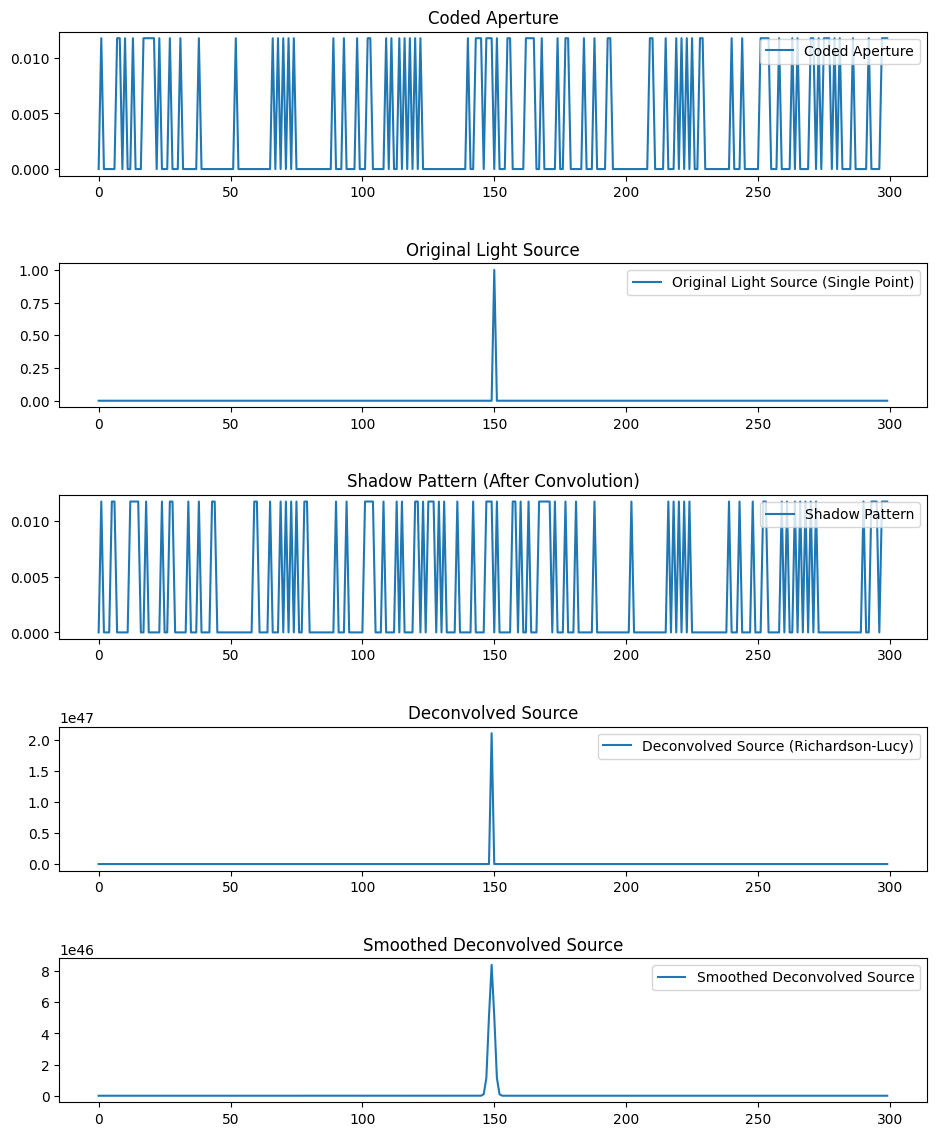

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter

def generate_coded_aperture(length, density):
    np.random.seed(0)
    aperture = np.random.choice([0, 1], size=length, p=[1 - density, density])
    aperture = aperture / np.sum(aperture)
    return aperture

def generate_point_source(length, position):
    source = np.zeros(length)
    source[position] = 1
    return source

def dft_convolution(source, aperture):
    N = len(source)
    source_dft = np.fft.fft(source)
    aperture_dft = np.fft.fft(aperture)
    shadow_dft = source_dft * aperture_dft
    shadow_pattern = np.fft.ifft(shadow_dft)
    return np.real(shadow_pattern)

def richardson_lucy(observed, psf, iterations=50):
    estimate = np.ones_like(observed)
    psf = psf / np.sum(psf)

    for _ in range(iterations):
        estimate_convolved = dft_convolution(estimate, psf)
        estimate_convolved[estimate_convolved == 0] = 1e-10
        relative_blur = observed / estimate_convolved
        psf_flipped = np.flip(psf)
        correction_factor = dft_convolution(relative_blur, psf_flipped)
        estimate *= correction_factor

    return estimate

def plot_results(aperture, source, shadow, deconvolved, deconvolved_smoothed):
    plt.figure(figsize=(10, 12))

    plt.subplot(5, 1, 1)
    plt.plot(aperture, label='Coded Aperture')
    plt.title('Coded Aperture')
    plt.legend()

    plt.subplot(5, 1, 2)
    plt.plot(source, label='Original Light Source (Single Point)')
    plt.title('Original Light Source')
    plt.legend()

    plt.subplot(5, 1, 3)
    plt.plot(shadow, label='Shadow Pattern')
    plt.title('Shadow Pattern (After Convolution)')
    plt.legend()

    plt.subplot(5, 1, 4)
    plt.plot(deconvolved, label='Deconvolved Source (Richardson-Lucy)')
    plt.title('Deconvolved Source')
    plt.legend()

    plt.subplot(5, 1, 5)
    plt.plot(deconvolved_smoothed, label='Smoothed Deconvolved Source')
    plt.title('Smoothed Deconvolved Source')
    plt.legend()

    plt.tight_layout(pad=3.0)
    plt.show()

if __name__ == "__main__":
    length = 300
    density = 0.3
    point_position = 150
    iterations = 50

    coded_aperture = generate_coded_aperture(length, density)
    light_source = generate_point_source(length, point_position)
    shadow_pattern = dft_convolution(light_source, coded_aperture)
    deconvolved_source = richardson_lucy(shadow_pattern, coded_aperture, iterations)
    deconvolved_source_smoothed = gaussian_filter(deconvolved_source, sigma=1)

    plot_results(coded_aperture, light_source, shadow_pattern, deconvolved_source, deconvolved_source_smoothed)
